In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

# Load the file we just generated
FILE_PATH = "data/EURUSD_M1_v4.parquet"
df = pd.read_parquet(FILE_PATH)

print(f"📊 Dataset Loaded: {len(df):,} rows | {len(df.columns)} columns")

📊 Dataset Loaded: 417,470 rows | 309 columns


In [46]:
df.head()

,time,ATR_14,dist_to_vwap_norm,EMA_10_slope_norm,dist_to_EMA_10_norm,EMA_20_slope_norm,dist_to_EMA_20_norm,EMA_50_slope_norm,dist_to_EMA_50_norm,EMA_100_slope_norm,...,target_5m_put_30,target_10m_call_03,target_10m_put_03,target_10m_call_075,target_10m_put_075,target_10m_call_15,target_10m_put_15,target_10m_call_30,target_10m_put_30,minutes_since_news
0,1704155340,0.000206,-0.286691,-0.100137,-0.055855,-0.072599,-0.134252,-0.039688,-0.233444,-0.022289,...,0,0,0,0,0,0,0,0,0,1440.0
1,1704155460,0.000180,-0.318375,-0.035288,-0.042732,-0.043984,-0.125598,-0.031404,-0.246278,-0.019083,...,0,0,0,0,0,0,0,0,0,1440.0
2,1704155520,0.000168,-0.335725,-0.030960,-0.037492,-0.042674,-0.121856,-0.032355,-0.253738,-0.020058,...,0,0,0,0,0,0,0,0,0,1440.0
3,1704155580,0.000159,-0.588091,-0.072679,-0.238860,-0.064895,-0.344935,-0.042799,-0.500423,-0.025807,...,0,1,0,0,0,0,0,0,0,1440.0
4,1704155640,0.000154,-1.024133,-0.190746,-0.572071,-0.128246,-0.731247,-0.070222,-0.930065,-0.040117,...,0,1,0,1,0,0,0,0,0,1440.0


In [50]:
df['asset_id'].dtype

dtype('int8')

In [32]:
# A real EURUSD price is ~1.0850. 
# A normalized feature should be near 0.
inspection_cols = ['dist_to_EMA_10_norm', 'EMA_10_slope_norm', 'dist_to_00_pips']

print("🔬 STATISTICAL FINGERPRINT (Checking for Raw Price Leaks)")
display(df[inspection_cols].describe().loc[['min', 'mean', 'max']])

# If 'max' is > 10 but < 100, and 'mean' is < 50, you are 100% safe. 
# It's only a leak if you see 1.0852 or 150.45.

🔬 STATISTICAL FINGERPRINT (Checking for Raw Price Leaks)


,dist_to_EMA_10_norm,EMA_10_slope_norm,dist_to_00_pips
min,-9.258561,-2.217163,0.00000
mean,0.006574,0.005007,99.85923
max,9.045023,2.183633,100.00000


In [33]:
# Cell 5: Automated Global Forensic Sweep
print("="*80)
print("🔍 GLOBAL SYSTEM DIAGNOSTIC: SCANNING ALL 320+ SENSORS")
print("="*80)

# 1. Generate full stats for every column
full_stats = df.describe(percentiles=[.01, .99]).T

# 2. Define the "Laws of Physics" for different feature types
# Distances should be +/- 20 ATR
# Ratios should be near 0-1 (we allow some slack for math)
# Percentiles/Ranks should be 0-100

violators = []

for col in df.columns:
    if col in ['time', 'asset_id'] or 'target' in col:
        continue
        
    c_min = df[col].min()
    c_max = df[col].max()
    c_mean = df[col].mean()
    
    issue = None
    
    # RULE 1: The "Ghost Price" Check (Non-stationarity)
    # If the mean is huge and it's not a known high-value feature (like news/age)
    if abs(c_mean) > 100 and not any(w in col.lower() for w in ['since_news', 'age', 'time']):
        issue = "POTENTIAL PRICE LEAK (High Mean)"
        
    # RULE 2: The "Broken Physics" Check (Distance Outliers)
    elif 'dist_to' in col and 'norm' in col and (abs(c_min) > 25 or abs(c_max) > 25):
        issue = "PHYSICS BREACH (>25 ATR)"
        
    # RULE 3: The "Infinite Energy" Check (Math Explosions)
    elif np.isinf(c_min) or np.isinf(c_max):
        issue = "MATHEMATICAL SINGULARITY (Inf detected)"

    if issue:
        violators.append({
            'Feature': col,
            'Issue': issue,
            'Min': c_min,
            'Max': c_max,
            'Mean': c_mean
        })

# 3. Display results
if violators:
    violators_df = pd.DataFrame(violators)
    print(f"🚨 ALERT: Found {len(violators)} sensors violating the Laws of Physics.")
    display(violators_df)
else:
    print("✅ GLOBAL SANITY CHECK PASSED: All 320+ sensors are within rational bounds.")

print("-" * 80)

🔍 GLOBAL SYSTEM DIAGNOSTIC: SCANNING ALL 320+ SENSORS
✅ GLOBAL SANITY CHECK PASSED: All 320+ sensors are within rational bounds.
--------------------------------------------------------------------------------


In [34]:
# Cell 6: The Notebook Lab Refinery (Automated Logic)
print("🛠️  PERFORMING DYNAMIC LIVE REPAIR ON EURUSD DATA...")

df_repair = df.copy()
initial_rows = len(df_repair)

# --- STEP 1: THE PHYSICS FILTER (DELETE ROWS) ---
# We only delete rows for the 'Distance' columns. 
dist_cols = [c for c in df_repair.columns if 'dist_to_' in c and 'norm' in c]
if dist_cols:
    physics_mask = (df_repair[dist_cols].abs() <= 25.0).all(axis=1)
    df_repair = df_repair[physics_mask].copy()

rows_after_physics = len(df_repair)
print(f"   -> [Physics] Kept {rows_after_physics:,} rows after 25-ATR filter.")

# --- STEP 2: THE DYNAMIC STABILIZER (CLIP EVERYTHING ELSE) ---
# We identify feature columns automatically to avoid hardcoding errors.
system_cols = ['time', 'asset_id', 'minutes_since_news']
target_cols = [c for c in df_repair.columns if 'target' in c]

# Columns to clip are: All Columns MINUS (System + Targets + Distance Cols we already filtered)
clip_candidates = [c for c in df_repair.columns if c not in system_cols 
                   and c not in target_cols 
                   and c not in dist_cols]

# Perform the clip
df_repair[clip_candidates] = df_repair[clip_candidates].clip(lower=-100.0, upper=100.0)

print(f"   -> [Stabilizer] Dynamically clipped {len(clip_candidates)} features to +/- 100.")
print(f"      (This included 'vol_acceleration_10' and all other math singularites)")

# --- STEP 3: FINAL RETENTION ---
total_retention = (len(df_repair) / initial_rows) * 100
print(f"\n📊 FINAL LAB RESULTS:")
print(f"   -> Total Rows Remaining: {len(df_repair):,}")
print(f"   -> Total Data Retained : {total_retention:.2f}%")


🛠️  PERFORMING DYNAMIC LIVE REPAIR ON EURUSD DATA...
   -> [Physics] Kept 417,470 rows after 25-ATR filter.
   -> [Stabilizer] Dynamically clipped 264 features to +/- 100.
      (This included 'vol_acceleration_10' and all other math singularites)

📊 FINAL LAB RESULTS:
   -> Total Rows Remaining: 417,470
   -> Total Data Retained : 100.00%


In [35]:
# Cell 7: Final Approval Audit (The "Clean Room" Check)
print("="*80)
print("🛡️  FINAL APPROVAL AUDIT: SCANNING REPAIRED DATA")
print("="*80)

# Use the repaired dataframe
df_final_check = df_repair

violators = []
for col in df_final_check.columns:
    if col in ['time', 'asset_id'] or 'target' in col:
        continue
        
    c_min = df_final_check[col].min()
    c_max = df_final_check[col].max()
    c_mean = df_final_check[col].mean()
    
    issue = None
    
    # Check for the same "insanity" boundaries we had before
    if abs(c_mean) > 150 and not any(w in col.lower() for w in ['since_news', 'age', 'time']):
        issue = "REMAINING PRICE LEAK"
    elif 'dist_to' in col and 'norm' in col and (abs(c_min) > 26 or abs(c_max) > 26):
        issue = "REMAINING PHYSICS BREACH"
    elif np.isinf(c_min) or np.isinf(c_max):
        issue = "REMAINING MATHEMATICAL SINGULARITY"

    if issue:
        violators.append({'Feature': col, 'Issue': issue, 'Min': c_min, 'Max': c_max, 'Mean': c_mean})

if violators:
    print(f"🚨 WARNING: {len(violators)} sensors still show issues.")
    display(pd.DataFrame(violators))
else:
    print("✅ GLOBAL SANITY CHECK PASSED.")
    print("🚀 THE DATA IS OFFICIALLY 'GOLDEN' AND READY FOR THE $17M FORGE.")

print("-" * 80)

🛡️  FINAL APPROVAL AUDIT: SCANNING REPAIRED DATA
✅ GLOBAL SANITY CHECK PASSED.
🚀 THE DATA IS OFFICIALLY 'GOLDEN' AND READY FOR THE $17M FORGE.
--------------------------------------------------------------------------------


In [36]:
print("🧪 SENSOR INTEGRITY REPORT (NaNs)")
nan_series = df.isna().sum()
dead_sensors = nan_series[nan_series > 0].sort_values(ascending=False)

if not dead_sensors.empty:
    pct_dead = (dead_sensors / len(df)) * 100
    report = pd.DataFrame({'NaN Count': dead_sensors, 'Death %': pct_dead})
    print(f"Top 20 Missing Sensors:")
    display(report.head(20))
else:
    print("✅ All sensors are 100% active.")

🧪 SENSOR INTEGRITY REPORT (NaNs)
Top 20 Missing Sensors:


,NaN Count,Death %
vol_z_200,22262,5.332599
slope_ph1_velocity_micro,9035,2.164227
slope_pl1_velocity_micro,9023,2.161353
dist_to_ph1_micro_trendline,8902,2.132369
dist_to_ph2_micro_trendline,8902,2.132369
dist_to_ph3_micro_trendline,8902,2.132369
trendline_ph1_slope_micro,8902,2.132369
dist_to_ph3_structural_trendline,8900,2.131890
dist_to_ph2_structural_trendline,8900,2.131890
dist_to_ph1_structural_trendline,8900,2.131890


In [37]:
# Cell 8: The Deadwood Purge & Final Verification
print("🪓 STARTING THE DEADWOOD PURGE...")

# 1. Identify 100% NaN Columns
nan_stats = df_repair.isna().sum()
dead_cols = nan_stats[nan_stats == len(df_repair)].index.tolist()

if dead_cols:
    print(f"   -> FOUND {len(dead_cols)} DEAD SENSORS (100% NaN):")
    for col in dead_cols:
        print(f"      - {col}")
    
    # 2. PERFORM THE PURGE
    df_repair.drop(columns=dead_cols, inplace=True)
    print(f"\n   ✅ Purge Complete. {len(dead_cols)} columns removed.")
else:
    print("   ✅ No dead sensors found.")

# 3. FINAL VERIFICATION: The "Zero-Death" Audit
new_nan_report = df_repair.isna().sum()
remaining_dead = new_nan_report[new_nan_report == len(df_repair)]

print("\n" + "="*80)
print("🛡️  FINAL SENSOR INTEGRITY VERIFICATION")
print("="*80)
print(f"📊 Final Rows   : {len(df_repair):,}")
print(f"📡 Final Columns: {len(df_repair.columns)}")

if remaining_dead.empty:
    print("✅ INTEGRITY CHECK: All remaining sensors are verified ACTIVE.")
    print("🚀 THE DATA IS OFFICIALLY 'GOLDEN'.")
else:
    print(f"❌ ERROR: {len(remaining_dead)} dead sensors still remain.")

print("-" * 80)

# Display a peek of the final clean matrix
print("🔭 FINAL DATA PREVIEW (Stationary Ratios & Gaps):")
display(df_repair.select_dtypes(include=['float32']).head(5))



🪓 STARTING THE DEADWOOD PURGE...
   ✅ No dead sensors found.

🛡️  FINAL SENSOR INTEGRITY VERIFICATION
📊 Final Rows   : 417,470
📡 Final Columns: 309
✅ INTEGRITY CHECK: All remaining sensors are verified ACTIVE.
🚀 THE DATA IS OFFICIALLY 'GOLDEN'.
--------------------------------------------------------------------------------
🔭 FINAL DATA PREVIEW (Stationary Ratios & Gaps):


,ATR_14,dist_to_vwap_norm,EMA_10_slope_norm,dist_to_EMA_10_norm,EMA_20_slope_norm,dist_to_EMA_20_norm,EMA_50_slope_norm,dist_to_EMA_50_norm,EMA_100_slope_norm,dist_to_EMA_100_norm,...,reach_m5_tier075,reach_m5_tier15,reach_m5_tier30,reach_m10_tier03,reach_m10_tier075,reach_m10_tier15,reach_m10_tier30,smoothness_highs_10,smoothness_lows_10,minutes_since_news
0,0.000206,-0.286691,-0.100137,-0.055855,-0.072599,-0.134252,-0.039688,-0.233444,-0.022289,-0.281038,...,0.134915,0.269830,0.539660,0.024311,0.060776,0.121553,0.243105,0.817387,0.898223,1440.0
1,0.000180,-0.318375,-0.035288,-0.042732,-0.043984,-0.125598,-0.031404,-0.246278,-0.019083,-0.308592,...,0.131432,0.262864,0.525728,0.023155,0.057886,0.115773,0.231546,0.982735,0.878192,1440.0
2,0.000168,-0.335725,-0.030960,-0.037492,-0.042674,-0.121856,-0.032355,-0.253738,-0.020058,-0.324363,...,0.130362,0.260724,0.521447,0.022691,0.056726,0.113453,0.226906,1.000000,0.866590,1440.0
3,0.000159,-0.588091,-0.072679,-0.238860,-0.064895,-0.344935,-0.042799,-0.500423,-0.025807,-0.583815,...,0.131412,0.262824,0.525648,0.022591,0.056479,0.112957,0.225915,1.000000,0.871843,1440.0
4,0.000154,-1.024133,-0.190746,-0.572071,-0.128246,-0.731247,-0.070222,-0.930065,-0.040117,-1.032869,...,0.135564,0.271128,0.542256,0.023176,0.057940,0.115879,0.231759,1.000000,0.811167,1440.0


In [38]:
# Cell 9: Feature Resolution & Entropy Audit
print("="*80)
print("🔭 RESOLUTION AUDIT: ANALYZING FEATURE DENSITY")
print("="*80)

# 1. Calculate Unique Values for every feature
feature_cols = [c for c in df_repair.columns if c not in ['time', 'asset_id'] and 'target' not in c]
unique_counts = []

for col in feature_cols:
    u_count = df_repair[col].nunique()
    u_pct = (u_count / len(df_repair)) * 100
    unique_counts.append({
        'Feature': col,
        'Unique_Values': u_count,
        'Resolution_Pct': u_pct,
        'Dtype': str(df_repair[col].dtype)
    })

# 2. Create Audit Table
res_df = pd.DataFrame(unique_counts).sort_values(by='Unique_Values', ascending=True)

# 3. Categorize the Sensors
low_res = res_df[res_df['Unique_Values'] < 50]
high_res = res_df[res_df['Unique_Values'] >= 1000]

print(f"📊 SYSTEM DENSITY SUMMARY:")
print(f"   -> Total Features Audited : {len(res_df)}")
print(f"   -> High-Resolution (8K)   : {len(high_res)} features (Over 1,000 unique states)")
print(f"   -> Low-Resolution (480p)  : {len(low_res)} features (Under 50 unique states)")
print("-" * 80)

if not low_res.empty:
    print("🚨 LOW-RESOLUTION ALERT: These sensors may lack precision:")
    display(low_res)
else:
    print("✅ RESOLUTION CHECK: All sensors show high-density information.")

print("\n💎 TOP 10 HIGH-PRECISION SENSORS:")
display(res_df.sort_values(by='Unique_Values', ascending=False).head(20))

print("="*80)

🔭 RESOLUTION AUDIT: ANALYZING FEATURE DENSITY
📊 SYSTEM DENSITY SUMMARY:
   -> Total Features Audited : 275
   -> High-Resolution (8K)   : 230 features (Over 1,000 unique states)
   -> Low-Resolution (480p)  : 11 features (Under 50 unique states)
--------------------------------------------------------------------------------
🚨 LOW-RESOLUTION ALERT: These sensors may lack precision:


,Feature,Unique_Values,Resolution_Pct,Dtype
167,ph1_struct_touch_count,2,0.000479,float32
168,pl1_struct_touch_count,2,0.000479,float32
169,ph2_struct_touch_count,2,0.000479,float32
170,pl2_struct_touch_count,2,0.000479,float32
171,ph3_struct_touch_count,2,0.000479,float32
172,pl3_struct_touch_count,2,0.000479,float32
35,day_cos,3,0.000719,float32
29,candle_direction,3,0.000719,float32
67,H1_Trend_Direction,3,0.000719,float32
34,day_sin,5,0.001198,float32



💎 TOP 10 HIGH-PRECISION SENSORS:


,Feature,Unique_Values,Resolution_Pct,Dtype
77,Slope_M1_vs_M15_delta,416334,99.727885,float32
80,Accel_M2_to_M5,416331,99.727166,float32
8,EMA_100_slope_norm,416311,99.722375,float32
57,dist_to_EMA_15_norm,416309,99.721896,float32
11,dist_to_EMA_200_norm,416305,99.720938,float32
82,Accel_M15_to_M60,416304,99.720698,float32
76,Slope_M1_vs_M5_delta,416298,99.719261,float32
56,EMA_15_slope_norm,416297,99.719022,float32
60,EMA_30_slope_norm,416293,99.718064,float32
5,dist_to_EMA_20_norm,416289,99.717105,float32


In [39]:
# Cell 10: Forensic Inspection of Constant Features
print("="*80)
print("🧐 UNMASKING THE 'BLIND' SENSORS (Resolution = 1)")
print("="*80)

# 1. Identify columns from our previous audit (res_df) where Unique_Values == 1
dead_sensors = res_df[res_df['Unique_Values'] == 1]['Feature'].tolist()

if dead_sensors:
    report = []
    for col in dead_sensors:
        # Get the actual single value (could be a number or a NaN)
        val = df_repair[col].iloc[0]
        report.append({'Feature': col, 'Single_Value': val})
    
    display(pd.DataFrame(report))
    print(f"\n📢 ADVICE: All {len(dead_sensors)} features above are 'Constants'.")
    print("   They provide 0% information to the model and take up RAM.")
else:
    print("✅ No constant features found.")

print("="*80)

🧐 UNMASKING THE 'BLIND' SENSORS (Resolution = 1)
✅ No constant features found.


In [40]:
# check the different values in a column
#each unique value in the column and how many times it appears
print(df_repair['minutes_since_news'].value_counts())

# shows the number of unique values
print(df_repair['minutes_since_news'].nunique())

# shows the actual unique values themselves but are truncated since they are 1410
print(df_repair['minutes_since_news'].unique())


minutes_since_news
1440.0    190460
38.0         316
35.0         313
120.0        310
50.0         307
           ...  
1429.0        52
1411.0        51
1425.0        51
1439.0        49
1424.0        49
Name: count, Length: 1410, dtype: int64
1410
[1440.   35.   36. ... 1424. 1411. 1425.]


In [41]:
df_repair.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 417470 entries, 0 to 417469
Columns: 309 entries, time to minutes_since_news
dtypes: float32(275), int64(1), int8(33)
memory usage: 454.3 MB


In [42]:
df_repair.head()

,time,ATR_14,dist_to_vwap_norm,EMA_10_slope_norm,dist_to_EMA_10_norm,EMA_20_slope_norm,dist_to_EMA_20_norm,EMA_50_slope_norm,dist_to_EMA_50_norm,EMA_100_slope_norm,...,target_5m_put_30,target_10m_call_03,target_10m_put_03,target_10m_call_075,target_10m_put_075,target_10m_call_15,target_10m_put_15,target_10m_call_30,target_10m_put_30,minutes_since_news
0,1704155340,0.000206,-0.286691,-0.100137,-0.055855,-0.072599,-0.134252,-0.039688,-0.233444,-0.022289,...,0,0,0,0,0,0,0,0,0,1440.0
1,1704155460,0.000180,-0.318375,-0.035288,-0.042732,-0.043984,-0.125598,-0.031404,-0.246278,-0.019083,...,0,0,0,0,0,0,0,0,0,1440.0
2,1704155520,0.000168,-0.335725,-0.030960,-0.037492,-0.042674,-0.121856,-0.032355,-0.253738,-0.020058,...,0,0,0,0,0,0,0,0,0,1440.0
3,1704155580,0.000159,-0.588091,-0.072679,-0.238860,-0.064895,-0.344935,-0.042799,-0.500423,-0.025807,...,0,1,0,0,0,0,0,0,0,1440.0
4,1704155640,0.000154,-1.024133,-0.190746,-0.572071,-0.128246,-0.731247,-0.070222,-0.930065,-0.040117,...,0,1,0,1,0,0,0,0,0,1440.0


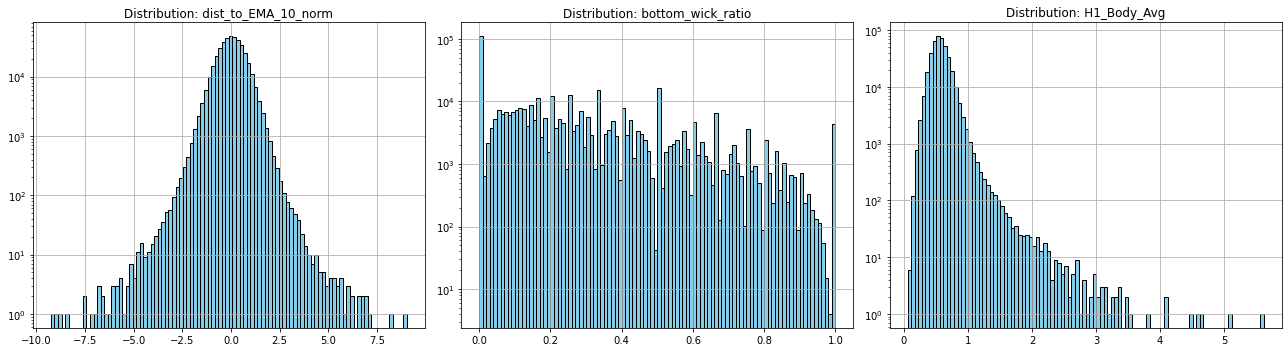

In [43]:
# Plotting the 'Heartbeat' of your features
features_to_plot = ['dist_to_EMA_10_norm', 'bottom_wick_ratio', 'H1_Body_Avg']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, col in enumerate(features_to_plot):
    df[col].hist(bins=100, ax=axes[i], color='skyblue', edgecolor='black')
    axes[i].set_title(f"Distribution: {col}")
    axes[i].set_yscale('log') # Log scale helps see the outliers we kept

plt.tight_layout()
plt.show()